In [2]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [5]:
### Get results from dir

param_decoding_results_dir = Path("parameter_decoding")
results_pkls = list(param_decoding_results_dir.rglob("*_r2_decoding_values*.pkl"))

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    if "audioset_only" in str(file_path):
        continue
    if 'pr2_invariant' not in results_dict.keys():
        continue 
    if 'no_shared' in str(file_path):
        continue
    # get files with ridge alpha in str 
    if  (file_path.stem.split('_')[-1] == '5e-01'):
        if 'barlow_dualtask_kell2018' in file_path.parent.name:
            continue
        results_df = pd.DataFrame.from_dict(results_dict)
        results_df['parameter'] = results_df.index
        results_df.reset_index(drop=True)
        results_df['layer'] = file_path.stem.split('_r2')[0]
        results_df['model'] = 'ResNet18' if 'resnet18' in str(file_path) else 'Kell2018'
        eq_lmbda = file_path.parent.stem.split('eq_lmbda_')[-1]
        if 'fixed' in eq_lmbda:
            eq_lmbda = eq_lmbda.split('_')[0]
        results_df['eq_lmbda'] = float(eq_lmbda)

        eq_model_base_name = file_path.parent.stem.split('equivariant_')[-1]
        results_df['ssl_training'] = 'equi.: SNR + b.g.' if 'w_invar_augment' in eq_model_base_name else "equi.: SNR + b.g. + augment"
        results_df['ssl_training'] = results_df['ssl_training'] + ' dual head' if 'dual' in eq_model_base_name else results_df['ssl_training']
        results_dfs.append(results_df)

        # if ix == 0:
        #     # mock invariant scores from first model as lmbda = 0.0 
        invar_df = results_df.copy(deep=True) 
        invar_df['eq_lmbda'] = 0.0 
        invar_df['ssl_training'] = 'invar.'
        invar_df['r2_equivariant'] = invar_df['r2_invariant']
        invar_df['pr2_equivariant'] = invar_df['pr2_invariant']
        results_dfs.append(invar_df)

    # break

results = pd.concat(results_dfs, axis=0, ignore_index = True).drop_duplicates()

In [6]:
results

,r2_invariant,r2_equivariant,pr2_invariant,pr2_equivariant,parameter,layer,model,eq_lmbda,ssl_training
0,0.781422,0.824469,0.782099,0.825837,dB SNR,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
1,0.450698,0.490002,0.464818,0.513975,Pitch (semitones),relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
2,0.838326,0.857018,0.838506,0.857182,% Time warp,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
3,0.006678,0.215170,0.142439,0.294347,Filter order,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
4,0.537274,0.665507,0.538621,0.667769,Filter low cutoff,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
...,...,...,...,...,...,...,...,...,...
1141,0.572072,0.542957,0.575991,0.544770,Pitch (semitones),layer2,ResNet18,0.4,equi.: SNR + b.g. + augment
1142,0.901964,0.913963,0.902208,0.914050,% Time warp,layer2,ResNet18,0.4,equi.: SNR + b.g. + augment
1143,0.562977,0.604438,0.565677,0.606559,Filter order,layer2,ResNet18,0.4,equi.: SNR + b.g. + augment
1144,0.782181,0.806906,0.784056,0.807574,Filter low cutoff,layer2,ResNet18,0.4,equi.: SNR + b.g. + augment


## Plot Kell2018 models

Text(0.5, 0, '$\\lambda$')

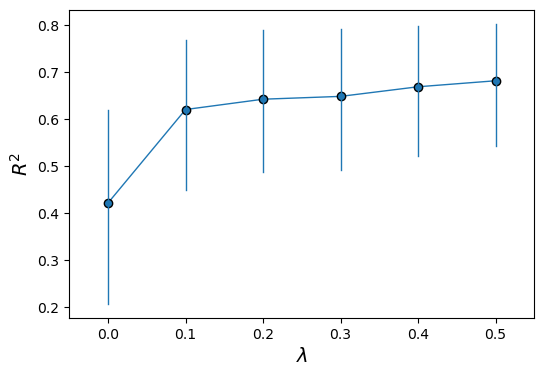

In [ ]:
kell_results = results[results.model.str.contains('Kell')].reset_index(drop=True)

fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.pointplot(data=kell_results[kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            # errorbar=('sd'),
            # hue='parameter',
            ax=ax,
            mec='k',
            mew=1,
            lw=1, ms=6
)

g.set_ylabel('$R^2$', fontsize=14)
g.set_xlabel('$\\lambda$', fontsize=14)
# g.legend(frameon=False, fontsize=10, title='Parameter', ncol=2)
# plt.savefig(outfig_dir/'relufc_param_decoding_avg_over_params.png', transparent=True,dpi=500,  bbox_inches='tight')


In [8]:
kell_results

,r2_invariant,r2_equivariant,pr2_invariant,pr2_equivariant,parameter,layer,model,eq_lmbda,ssl_training
0,0.781422,0.824469,0.782099,0.825837,dB SNR,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
1,0.450698,0.490002,0.464818,0.513975,Pitch (semitones),relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
2,0.838326,0.857018,0.838506,0.857182,% Time warp,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
3,0.006678,0.215170,0.142439,0.294347,Filter order,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
4,0.537274,0.665507,0.538621,0.667769,Filter low cutoff,relu4,Kell2018,0.0,equi.: SNR + b.g. + augment dual head
...,...,...,...,...,...,...,...,...,...
363,0.308055,0.339854,0.325951,0.355941,Pitch (semitones),relu0,Kell2018,0.2,equi.: SNR + b.g. + augment
364,0.842988,0.840367,0.843093,0.840564,% Time warp,relu0,Kell2018,0.2,equi.: SNR + b.g. + augment
365,0.359328,0.358513,0.390743,0.392846,Filter order,relu0,Kell2018,0.2,equi.: SNR + b.g. + augment
366,0.800483,0.806103,0.802225,0.807966,Filter low cutoff,relu0,Kell2018,0.2,equi.: SNR + b.g. + augment


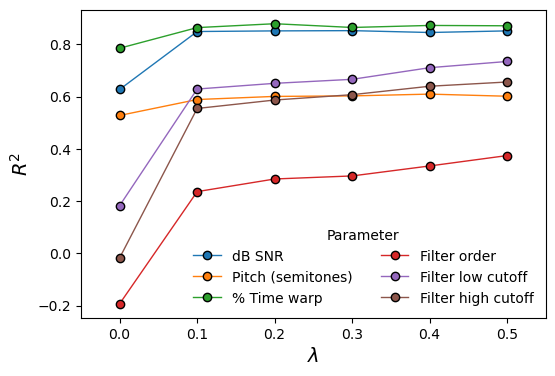

In [9]:
kell_results = results[results.model.str.contains('Kell') & ~results.ssl_training.str.contains('dual')].reset_index(drop=True)

fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.pointplot(data=kell_results[kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            # errorbar=('sd'),
            hue='parameter',
            ax=ax,
            mec='k',
            mew=1,
            lw=1, ms=6
)

g.set_ylabel('$R^2$', fontsize=14)
g.set_xlabel('$\\lambda$', fontsize=14)
g.legend(frameon=False, fontsize=10, title='Parameter', ncol=2)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True,dpi=500,  bbox_inches='tight')


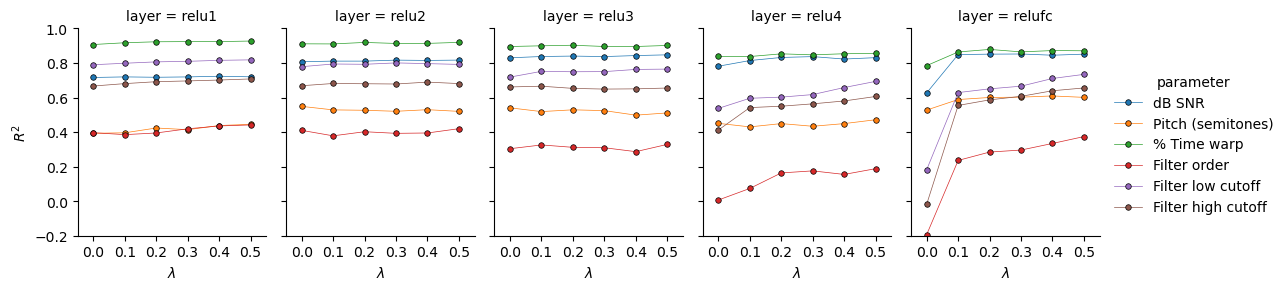

In [20]:
kell_results = results[results.model.str.contains('Kell') & ~results.ssl_training.str.contains('dual')].reset_index(drop=True)

# fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.catplot (
            kind='point',
            data=kell_results, # [kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            # errorbar=('sd'),
            hue='parameter',
            col='layer',
            col_order=
                ['relu1', 'relu2', 'relu3', 'relu4', 'relufc'],
            # ax=ax,
            mec='k',
            mew=0.5,
            lw=0.5,
            ms=4,
            height=3,
            aspect=0.75,
)
g.set(ylabel='$R^2$', 
      xlabel='$\\lambda$',
      ylim=(-0.2,1),
        # fontsize=14,
        )
# g.set_ylabel('$R^2$', fontsize=14)
# g.set_xlabel('$\\lambda$', fontsize=14)
# g.legend(frameon=False, fontsize=10, title='Parameter', ncol=2)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True,dpi=500,  bbox_inches='tight')


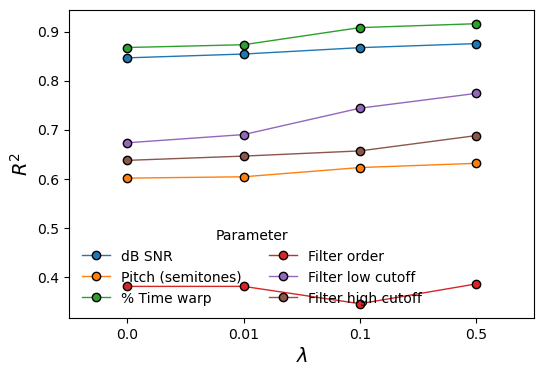

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(12,4))
kell_results = results[results.model.str.contains('Kell')].reset_index(drop=True)

g = sns.pointplot(data=kell_results[kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            # errorbar=('sd'),
            hue='parameter',
            ax = axs[0],
            mec='k',
            mew=1,
            lw=1, ms=6
)

g.set_ylabel('$R^2$', fontsize=14)
g.set_xlabel('$\\lambda$', fontsize=14)
g.legend(frameon=False, fontsize=10, title='Parameter', ncol=2)

kell_results = results[results.model.str.contains('Kell') & results.ssl_training.str.contains('dual')].reset_index(drop=True)

fig, ax = plt.subplots(1, figsize=(6,4))
g = sns.pointplot(data=kell_results[kell_results.layer=='relufc'],
            x='eq_lmbda',
            y='r2_equivariant',
            # errorbar=('sd'),
            hue='parameter',
            ax=ax,
            mec='k',
            mew=1,
            lw=1, ms=6
)

g.set_ylabel('$R^2$', fontsize=14)
g.set_xlabel('$\\lambda$', fontsize=14)
g.legend(frameon=False, fontsize=10, title='Parameter', ncol=2)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True,dpi=500,  bbox_inches='tight')


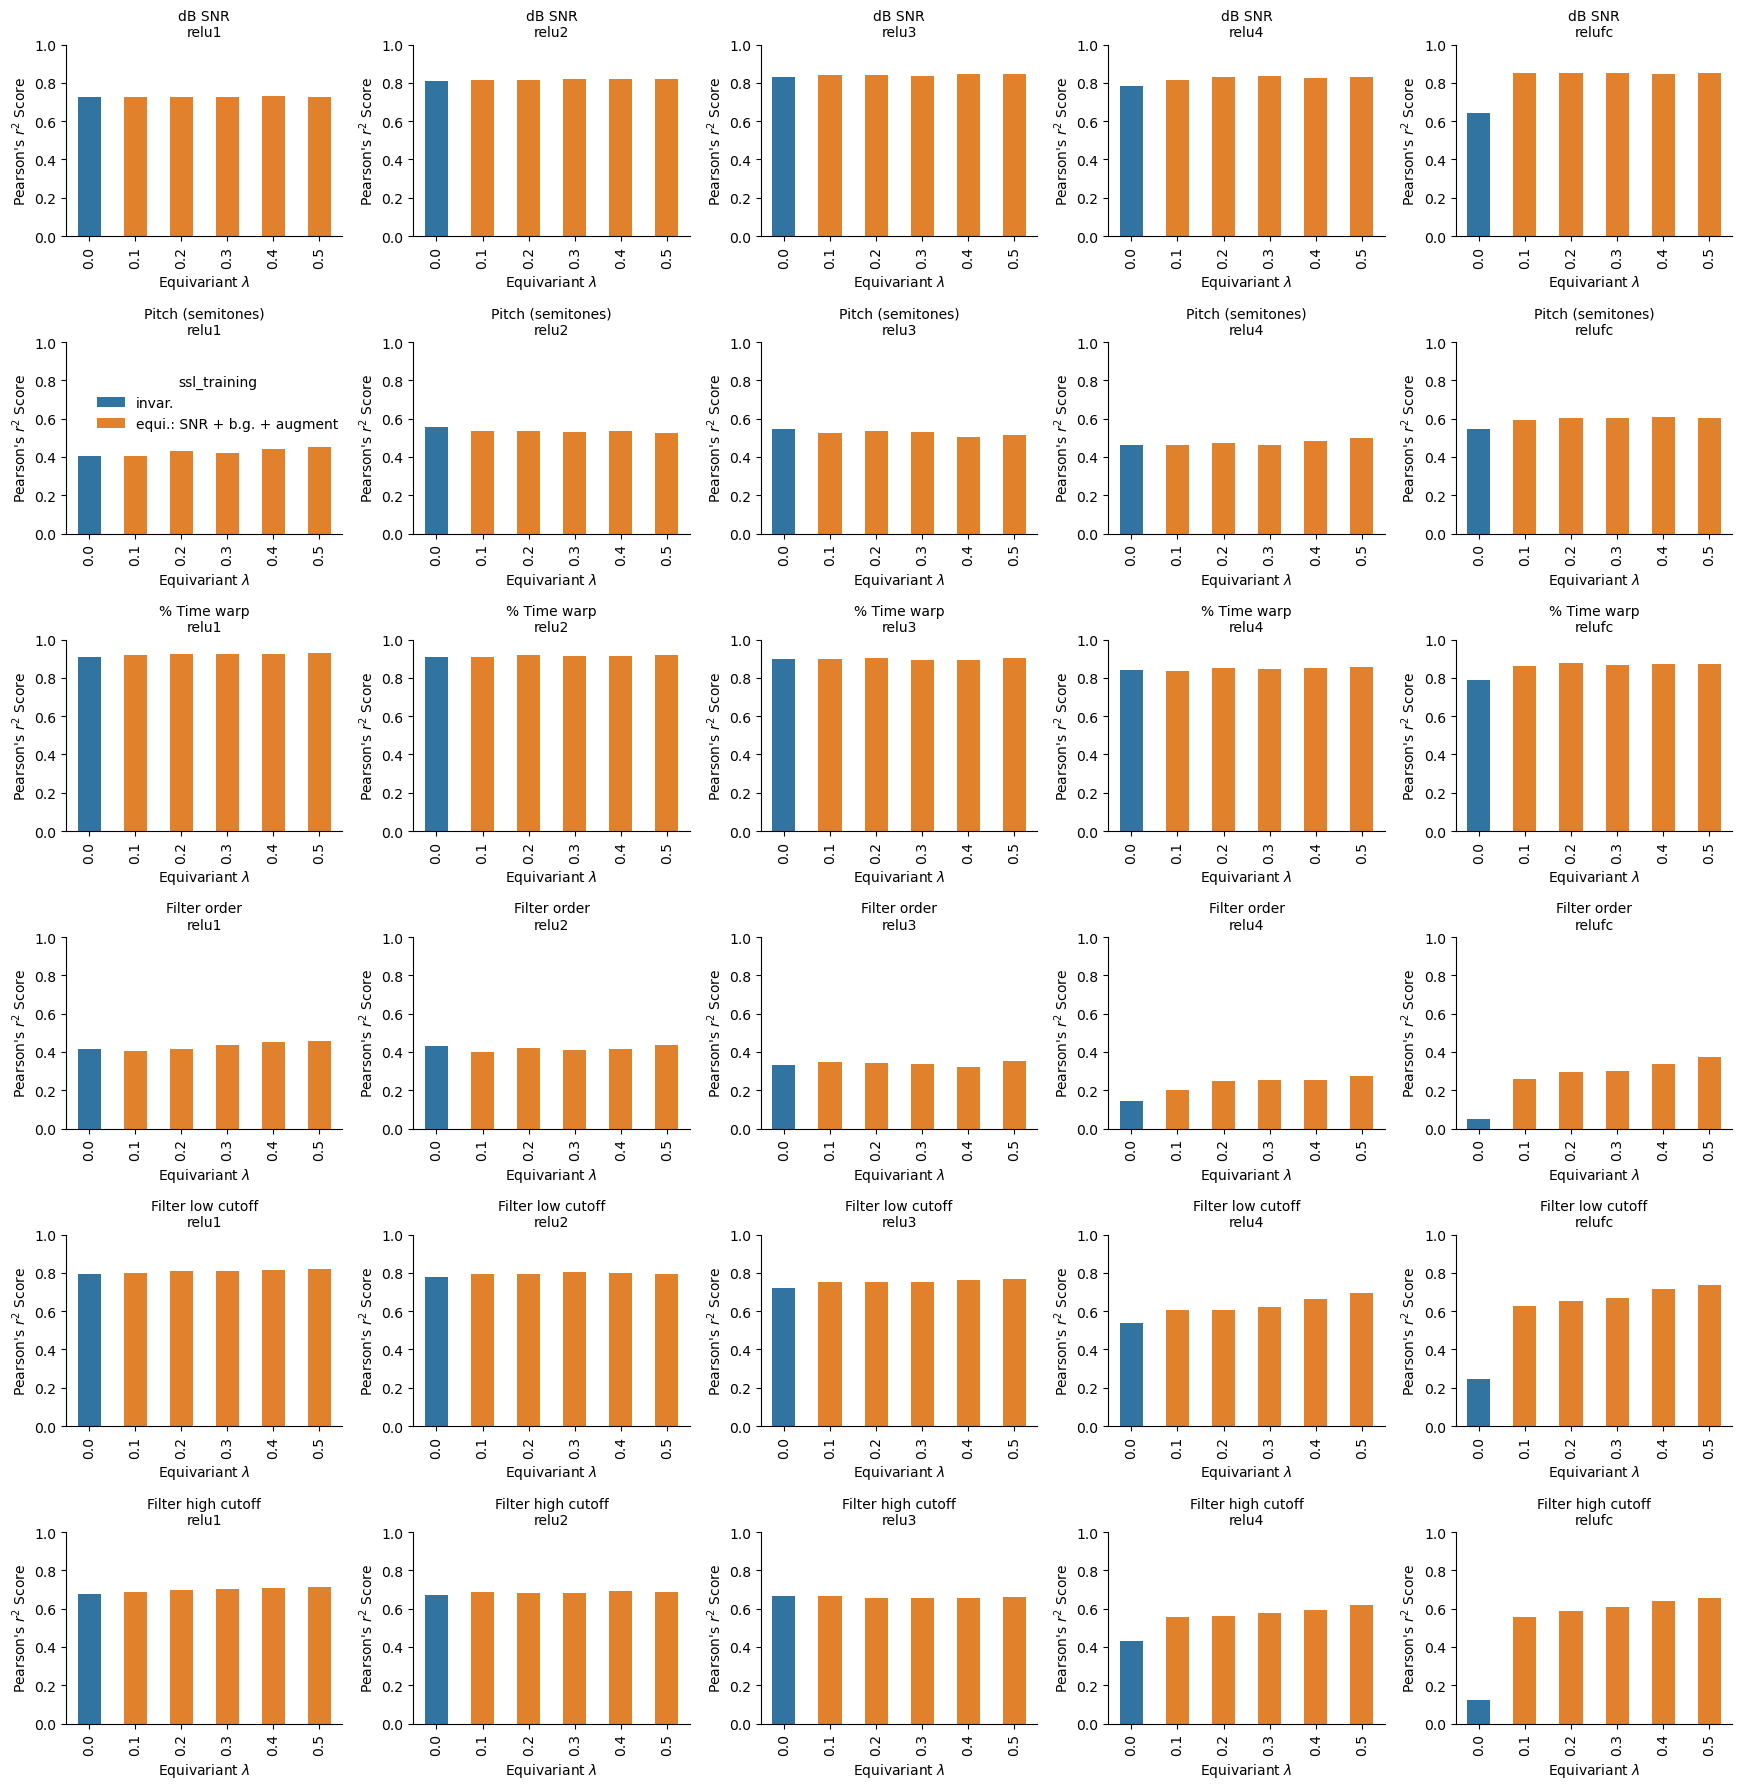

In [5]:
layer_order = [
            'relu1',
            'relu2', 
            'relu3',
            'relu4',
            'relufc'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=results[results.model == 'Kell2018'],
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='ssl_training', 
            row='parameter',
            col='layer', 
            col_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name}")
g.set(xlabel="Equivariant $\\lambda$", ylabel="Pearson's $r^2$ Score")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.2, 0.77])

plt.tight_layout()


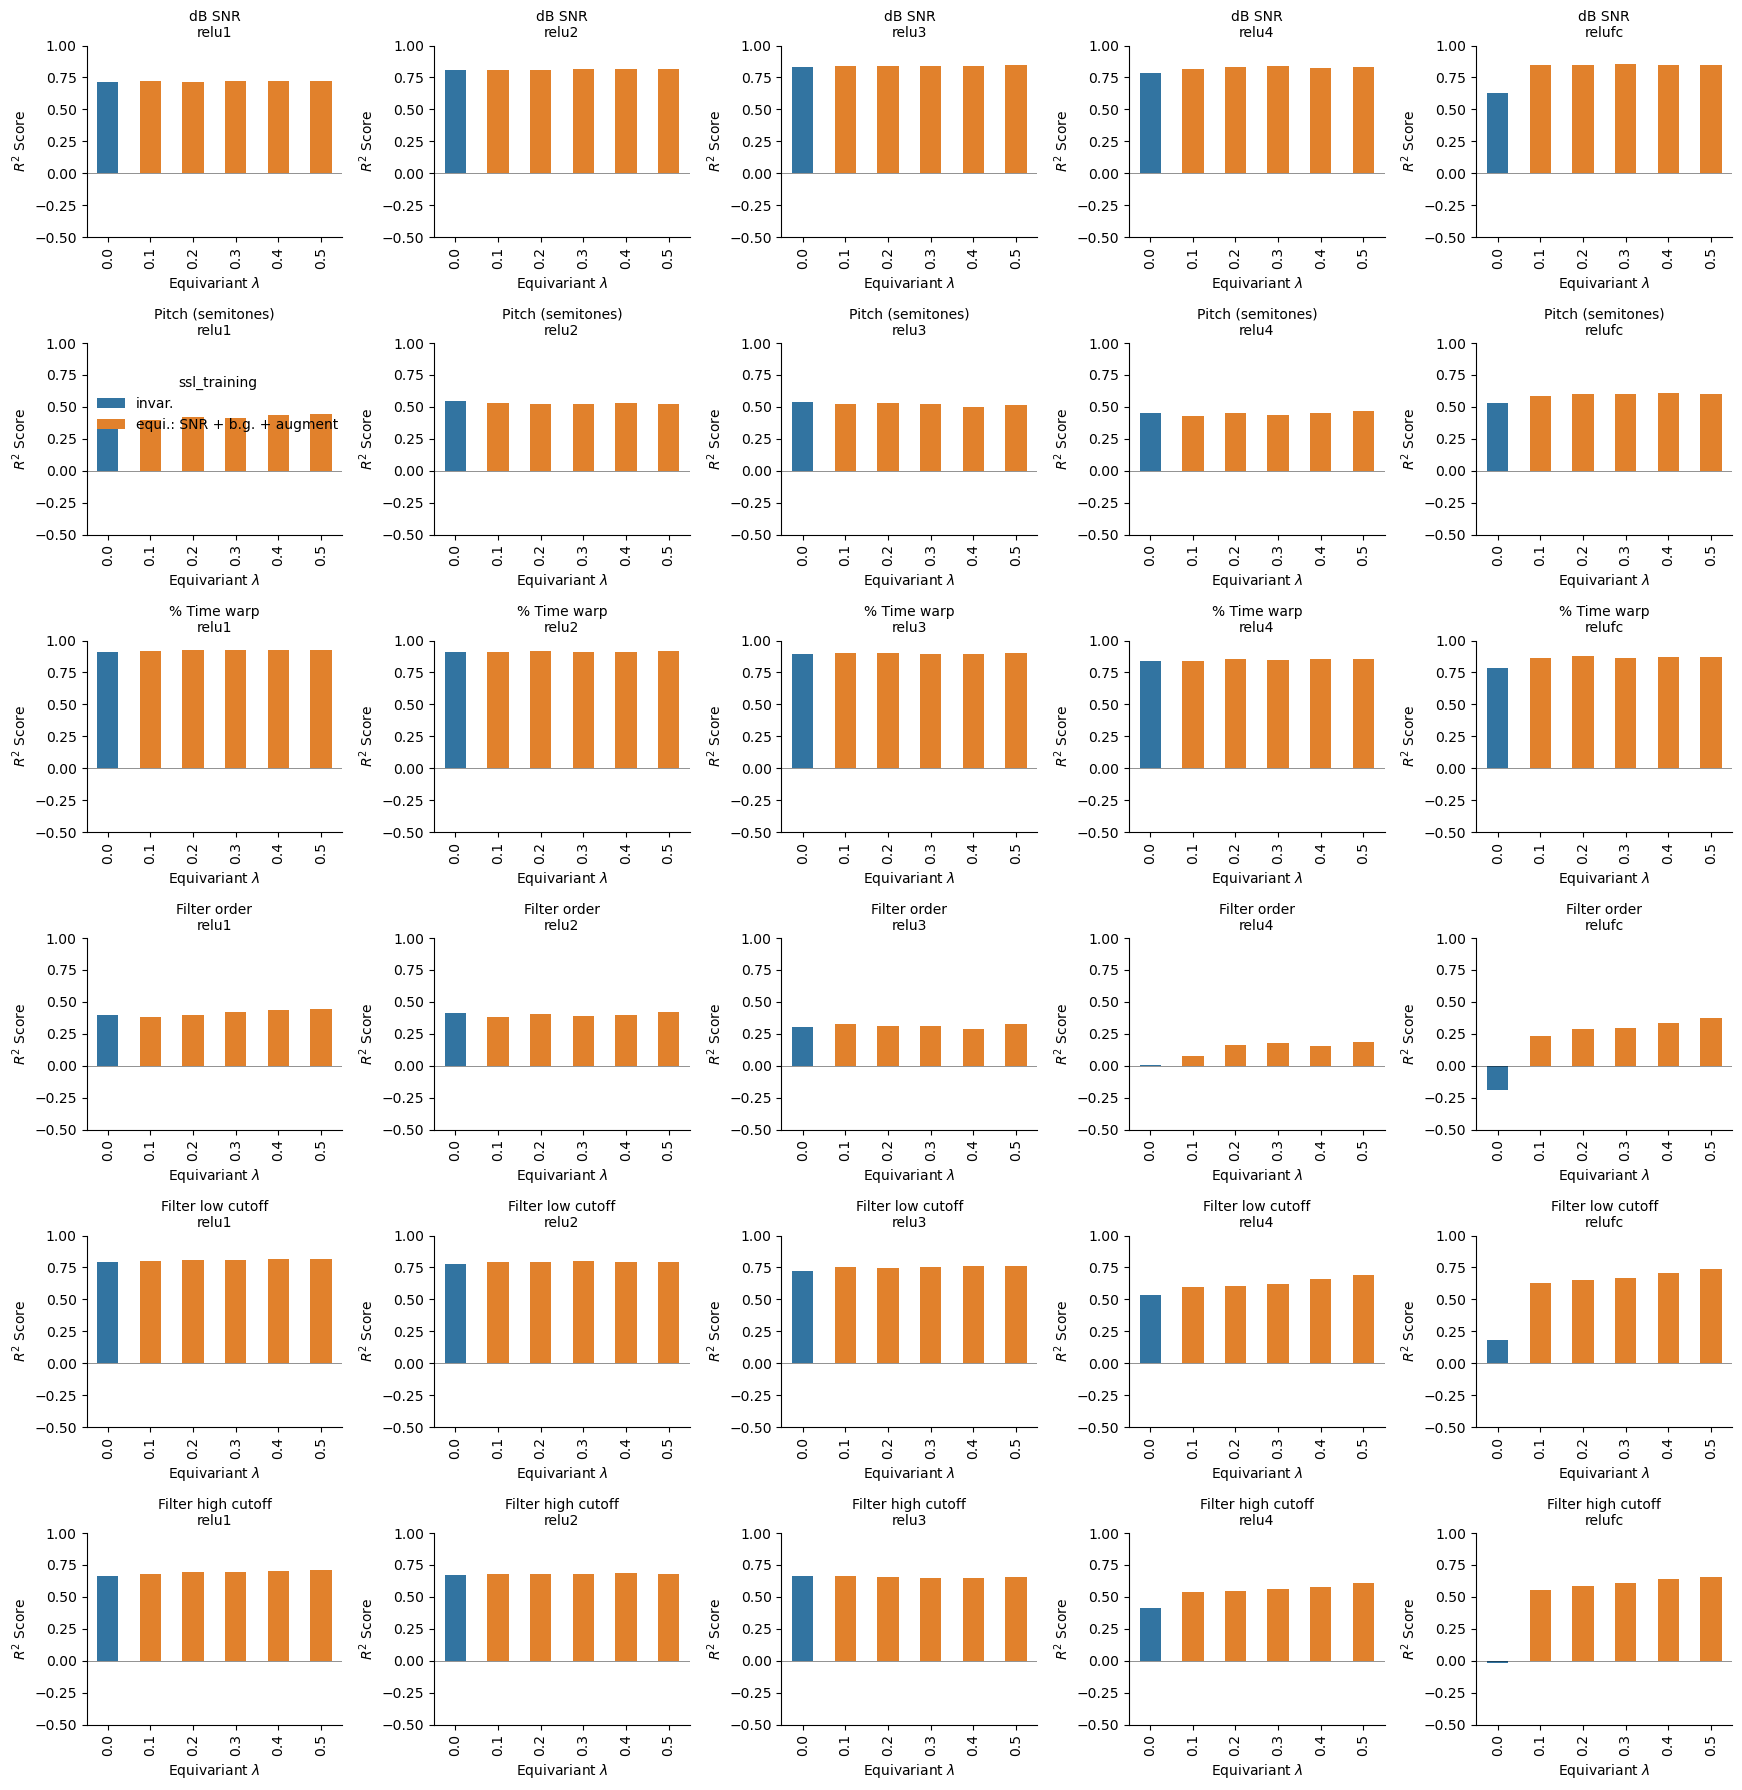

In [33]:
layer_order = [
            'relu1',
            'relu2', 
            'relu3',
            'relu4',
            'relufc'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=results[results.model == 'Kell2018'],
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='r2_equivariant', 
            hue='ssl_training', 
            row='parameter',
            col='layer', 
            col_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name}")
g.set(xlabel="Equivariant $\\lambda$", ylabel="$R^2$ Score")
g.set(ylim=(-0.5,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
g.refline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=0.5)

# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.2, 0.77])

plt.tight_layout()


## Plot ResNet18s

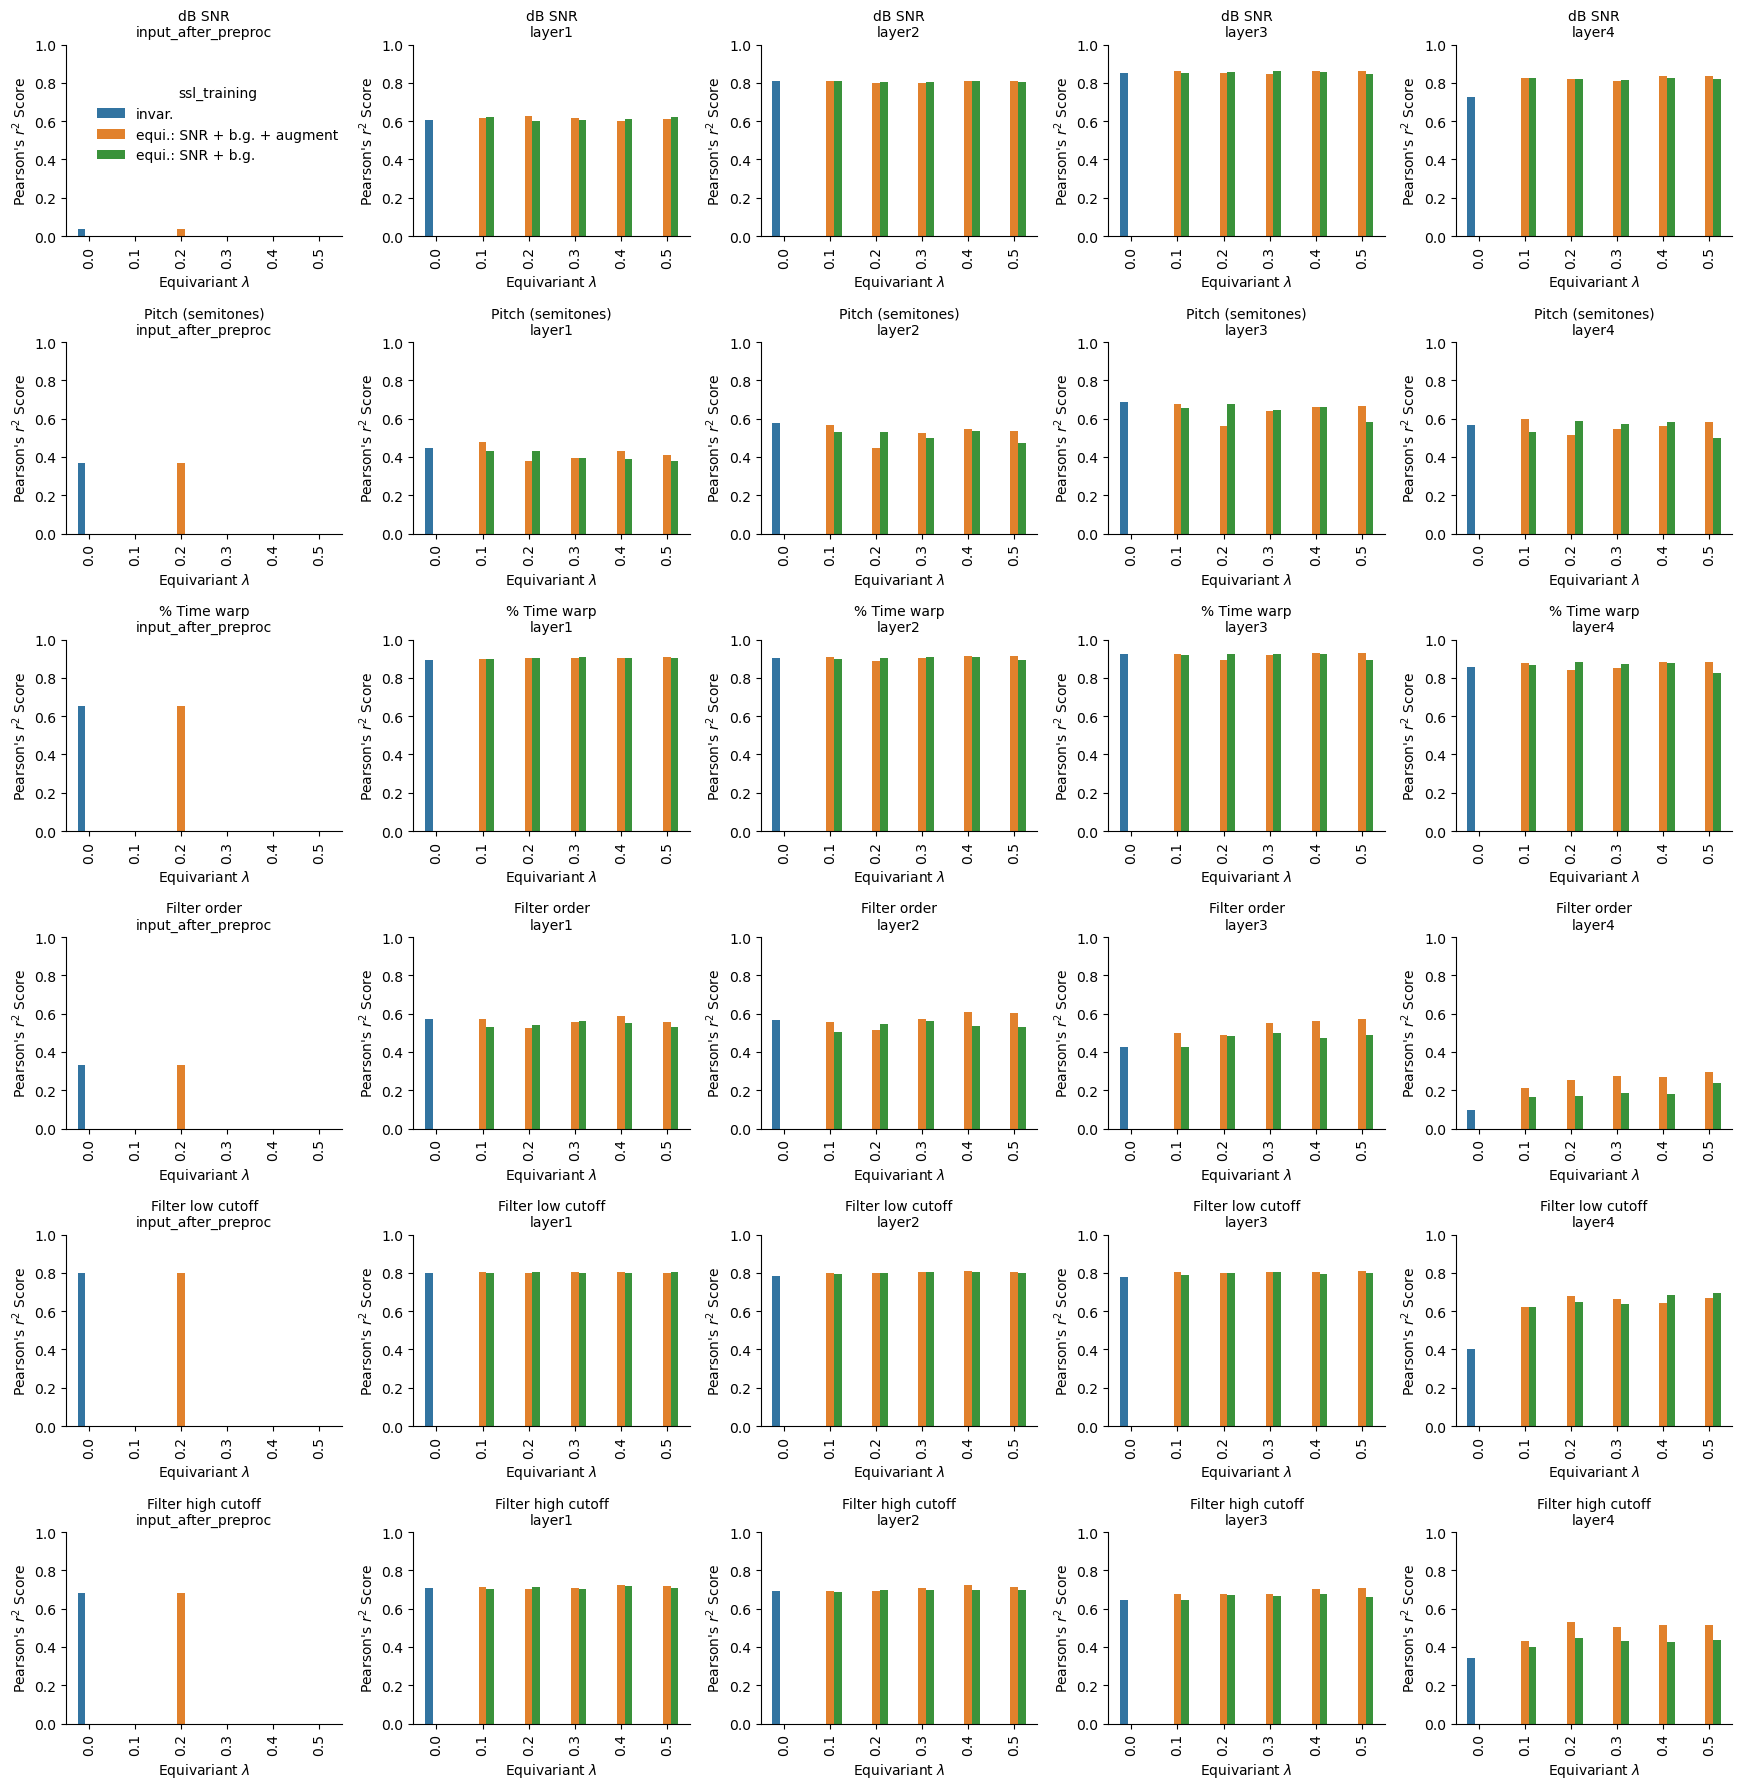

In [6]:
layer_order = [
            'input_after_preproc',
            'layer1',
            'layer2', 
            'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=results[results.model == 'ResNet18'],
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='ssl_training', 
            row='parameter',
            col='layer', 
            col_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name}")
g.set(xlabel="Equivariant $\\lambda$", ylabel="Pearson's $r^2$ Score")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.2, 0.925])

plt.tight_layout()


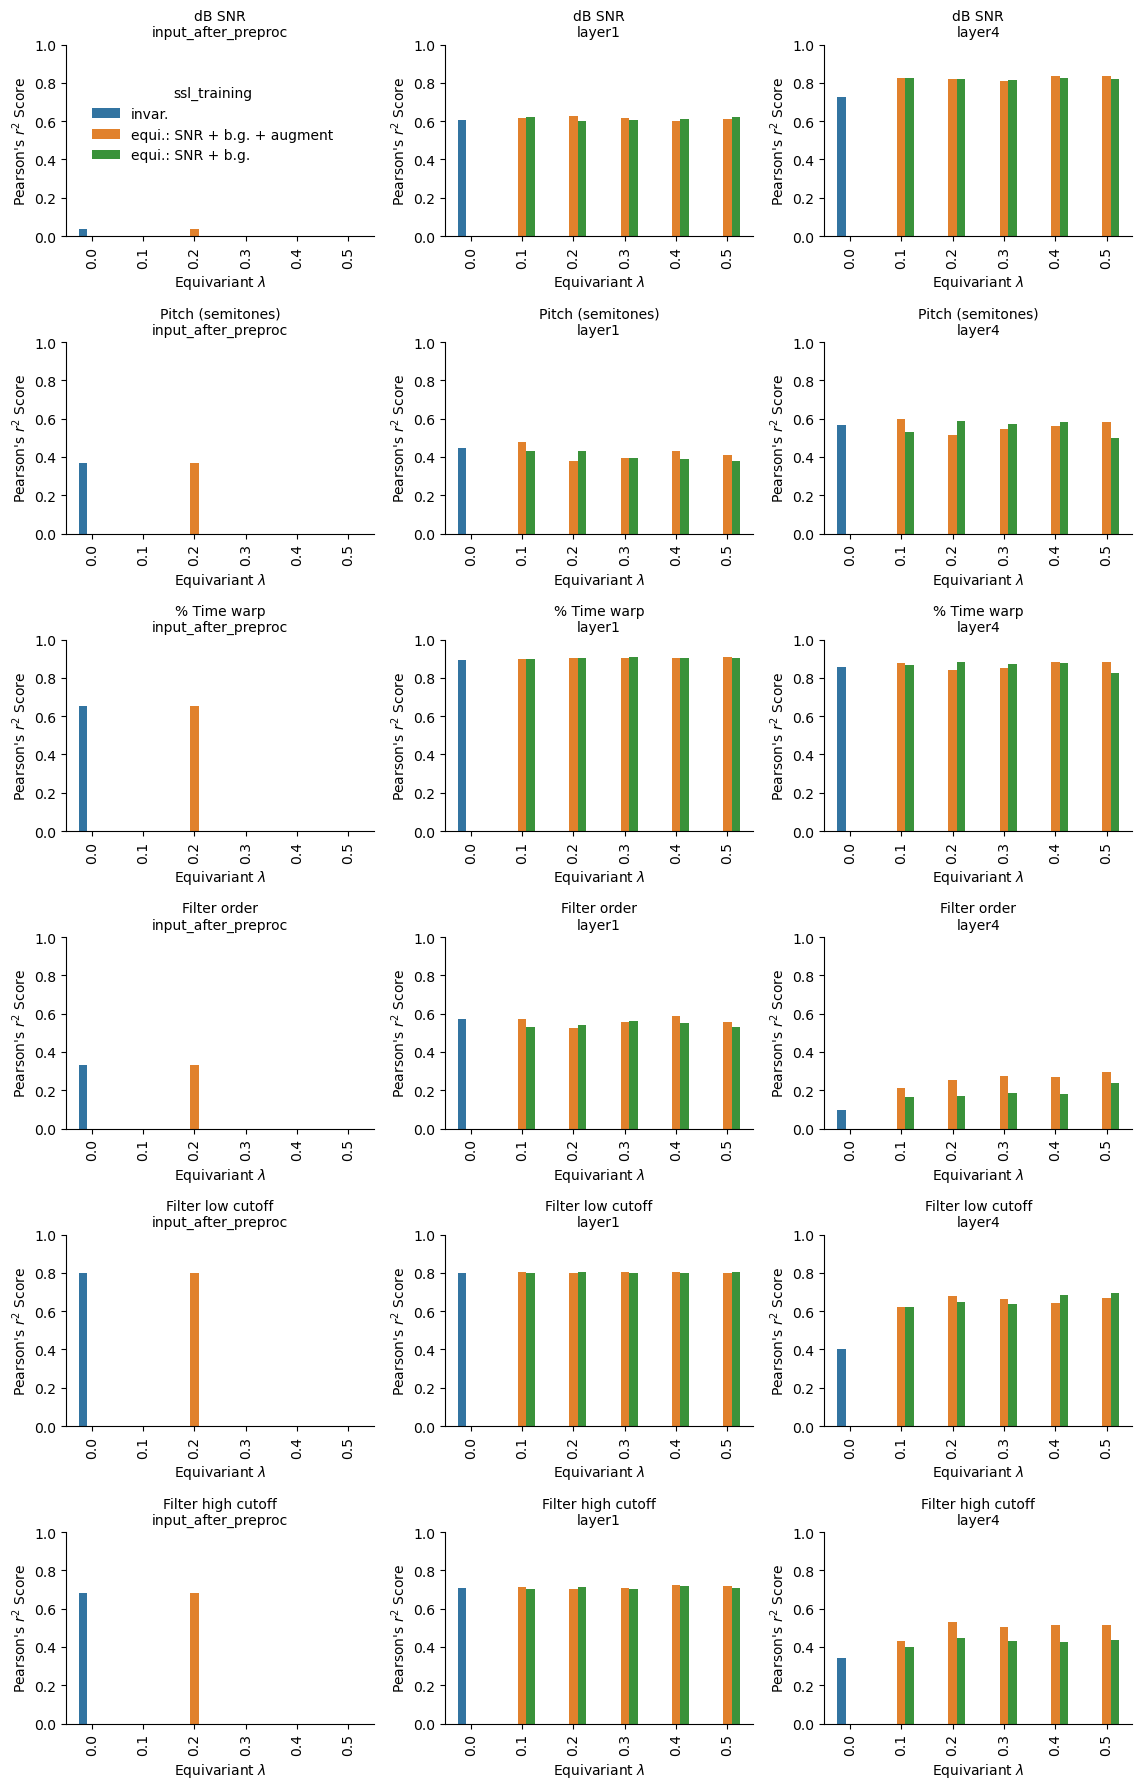

In [ ]:
layer_order = [
            'input_after_preproc',
            'layer1',
            # 'layer2', 
            # 'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='ssl_training', 
            row='parameter',
            col='layer', 
            col_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name}")
g.set(xlabel="Equivariant $\\lambda$", ylabel="Pearson's $r^2$ Score")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.3, 0.925])

plt.tight_layout()


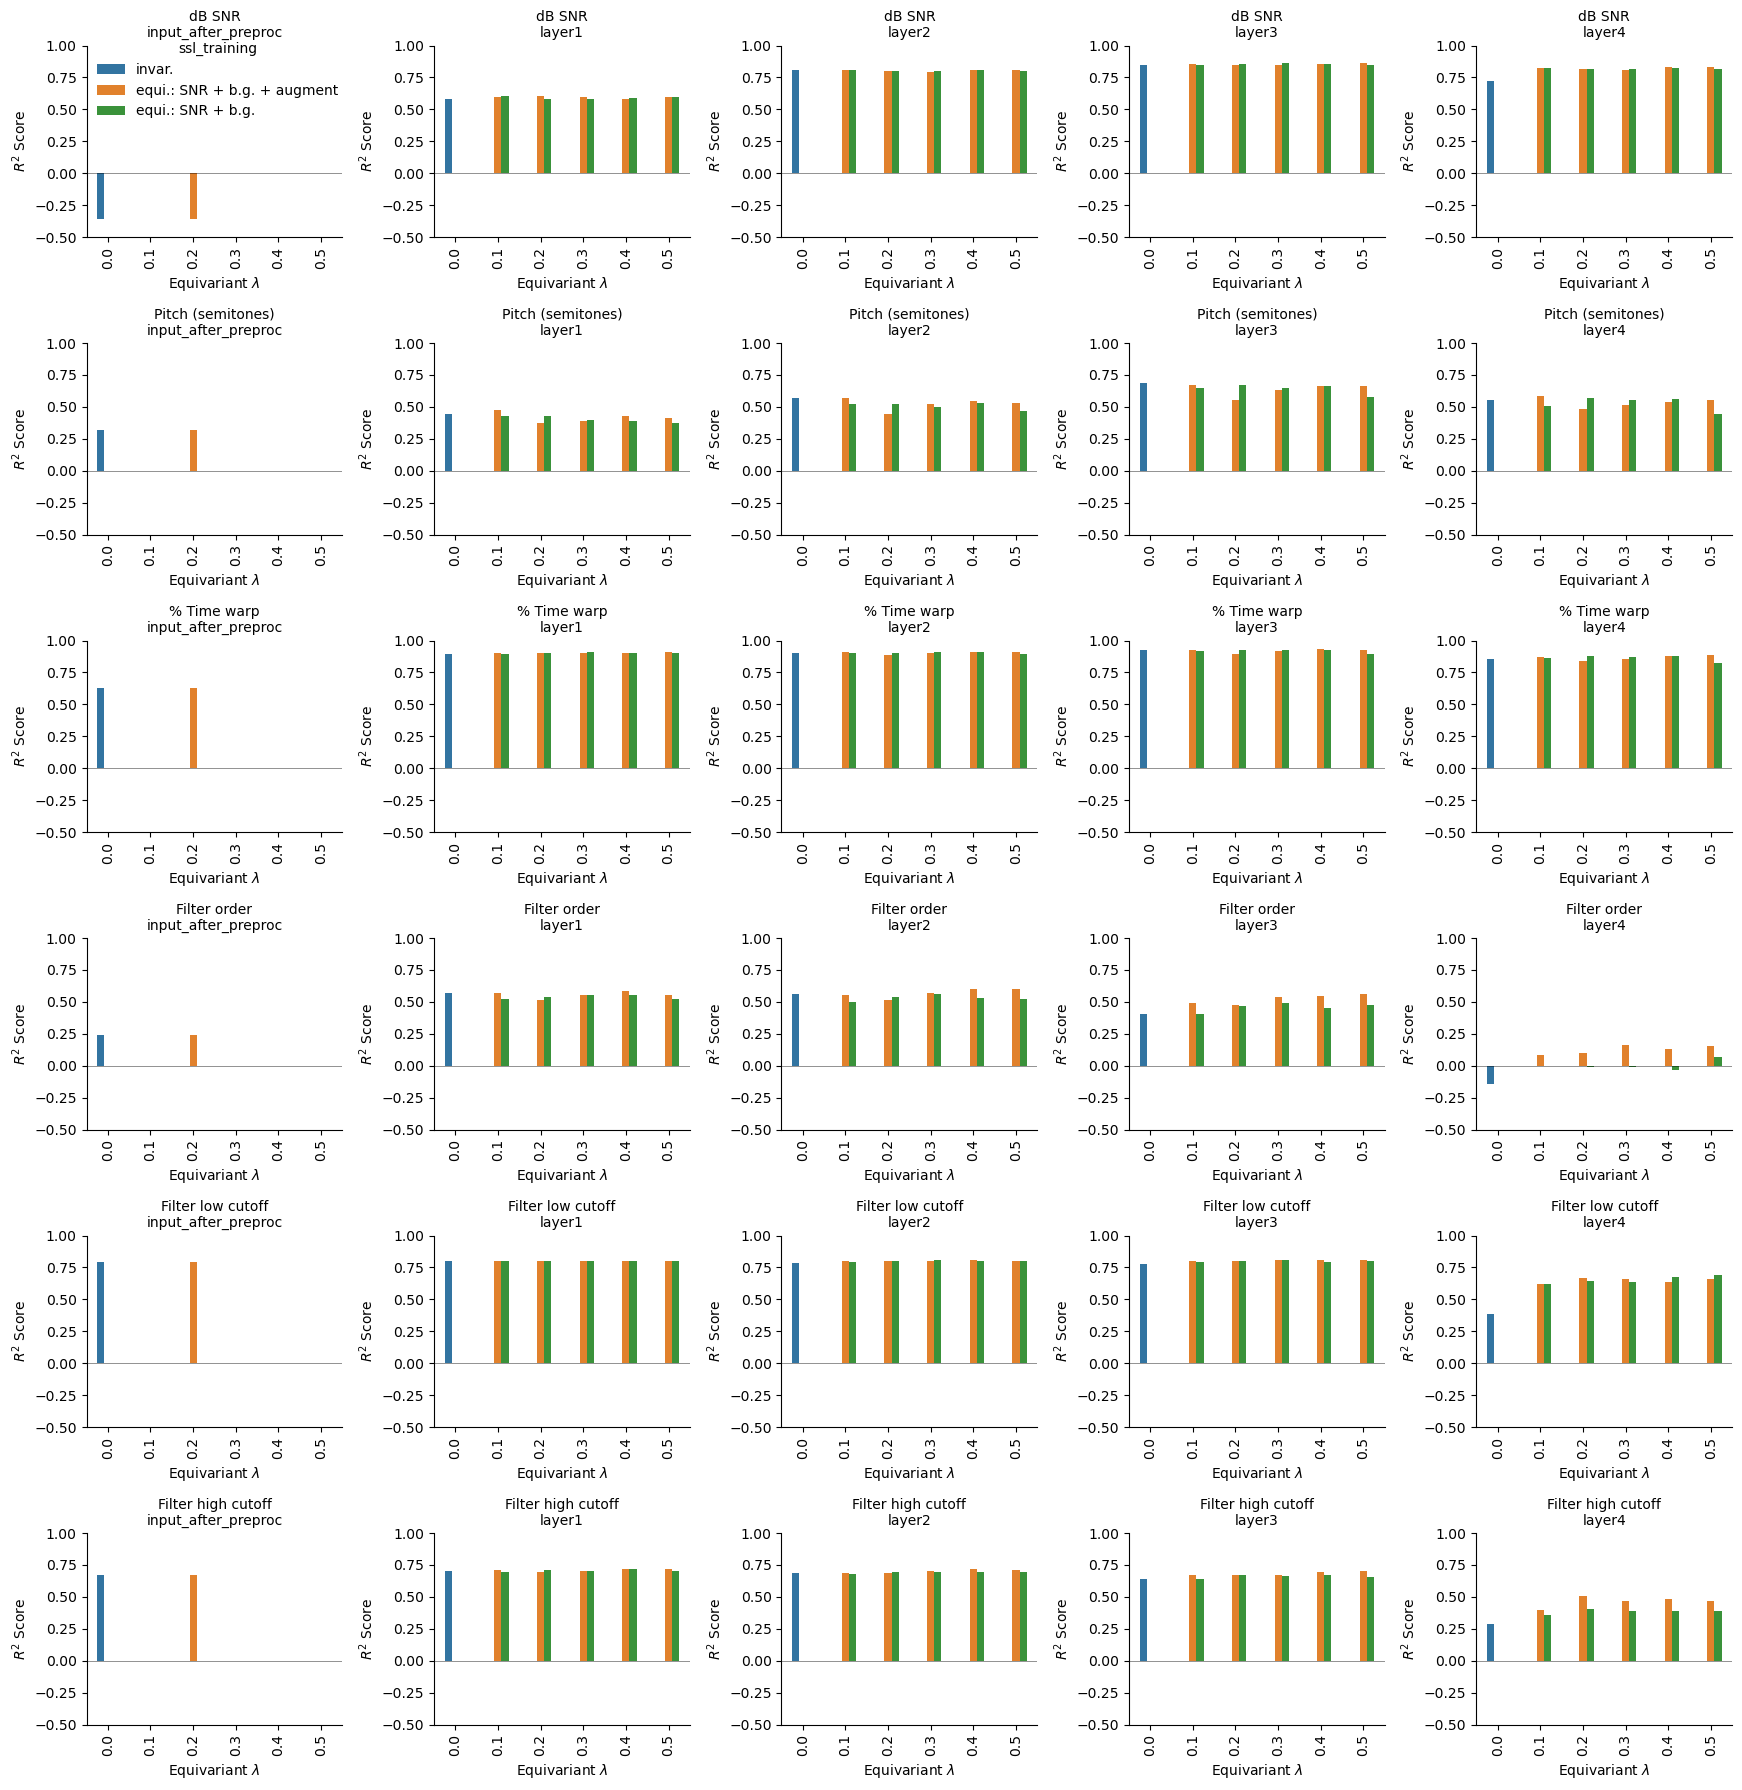

In [ ]:
layer_order = [
            'input_after_preproc',
            'layer1',
            'layer2', 
            'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())
# eq_lmbda_order = [0.1, 0.5]

g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='r2_equivariant', 
            hue='ssl_training', 
            row='parameter',
            col='layer', 
            col_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name}")
g.set(ylim=(-0.5,1))
g.set(xlabel="Equivariant $\\lambda$", ylabel="$R^2$ Score")
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
g.refline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=0.5)

# Access the legend object
leg = g._legend

# Set the legend's position (adjust the coordinates as needed)
leg.set_bbox_to_anchor([0.2, 0.95])
plt.tight_layout()


## Compare invariant and equivariant heads 

In [11]:
list(Path('parameter_decoding').rglob('*/invar_equivar_ssl_head_r2_decoding_values.pkl'))

[PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_5e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_2e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_2e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_4e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_3e-01/invar_equivar_ssl_head_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_equ

In [66]:
results_paths = list(Path('parameter_decoding').rglob('*/invar_equivar_ssl_head_r2_decoding_values.pkl'))
ssl_head_dfs = [] 
for filename in results_paths:
    results_dict = pd.read_pickle(filename)
    results_df = pd.DataFrame.from_dict(results_dict)
    results_df['parameter'] = results_df.index
    results_df.reset_index(drop=True)
    results_df['eq_lmbda'] = float(filename.parent.stem.split('eq_lmbda_')[-1])
    eq_model_base_name = filename.parent.stem.split('equivariant_')[-1]
    results_df['ssl_training'] = 'equi.: SNR + b.g.' if 'w_invar_augment' in eq_model_base_name else "equi.: SNR + b.g. + augment"
    ssl_head_dfs.append(results_df)

ssl_head_df = pd.concat(ssl_head_dfs, ignore_index=True)
ssl_head_df = pd.melt(ssl_head_df, id_vars=['parameter', 'eq_lmbda', 'ssl_training'], var_name='r2_fit', value_name='score' )

ssl_head_df['measure'] = ssl_head_df.r2_fit.apply(lambda x: 'pr2' if 'pr2' in x else 'r2')
ssl_head_df['task_head'] = ssl_head_df.r2_fit.str.extract(r'^[^_]+_([^_]+)_[^_]+$')
ssl_head_df

,parameter,eq_lmbda,ssl_training,r2_fit,score,measure,task_head
0,dB SNR,0.5,equi.: SNR + b.g. + augment,r2_invariant_head,-0.066736,r2,invariant
1,Pitch (semitones),0.5,equi.: SNR + b.g. + augment,r2_invariant_head,0.379923,r2,invariant
2,% Time warp,0.5,equi.: SNR + b.g. + augment,r2_invariant_head,-0.005975,r2,invariant
3,Filter order,0.5,equi.: SNR + b.g. + augment,r2_invariant_head,0.013268,r2,invariant
4,Filter low cutoff,0.5,equi.: SNR + b.g. + augment,r2_invariant_head,0.079277,r2,invariant
...,...,...,...,...,...,...,...
235,Pitch (semitones),0.1,equi.: SNR + b.g.,pr2_equivariant_head,0.071449,pr2,equivariant
236,% Time warp,0.1,equi.: SNR + b.g.,pr2_equivariant_head,0.535498,pr2,equivariant
237,Filter order,0.1,equi.: SNR + b.g.,pr2_equivariant_head,0.101338,pr2,equivariant
238,Filter low cutoff,0.1,equi.: SNR + b.g.,pr2_equivariant_head,0.260080,pr2,equivariant


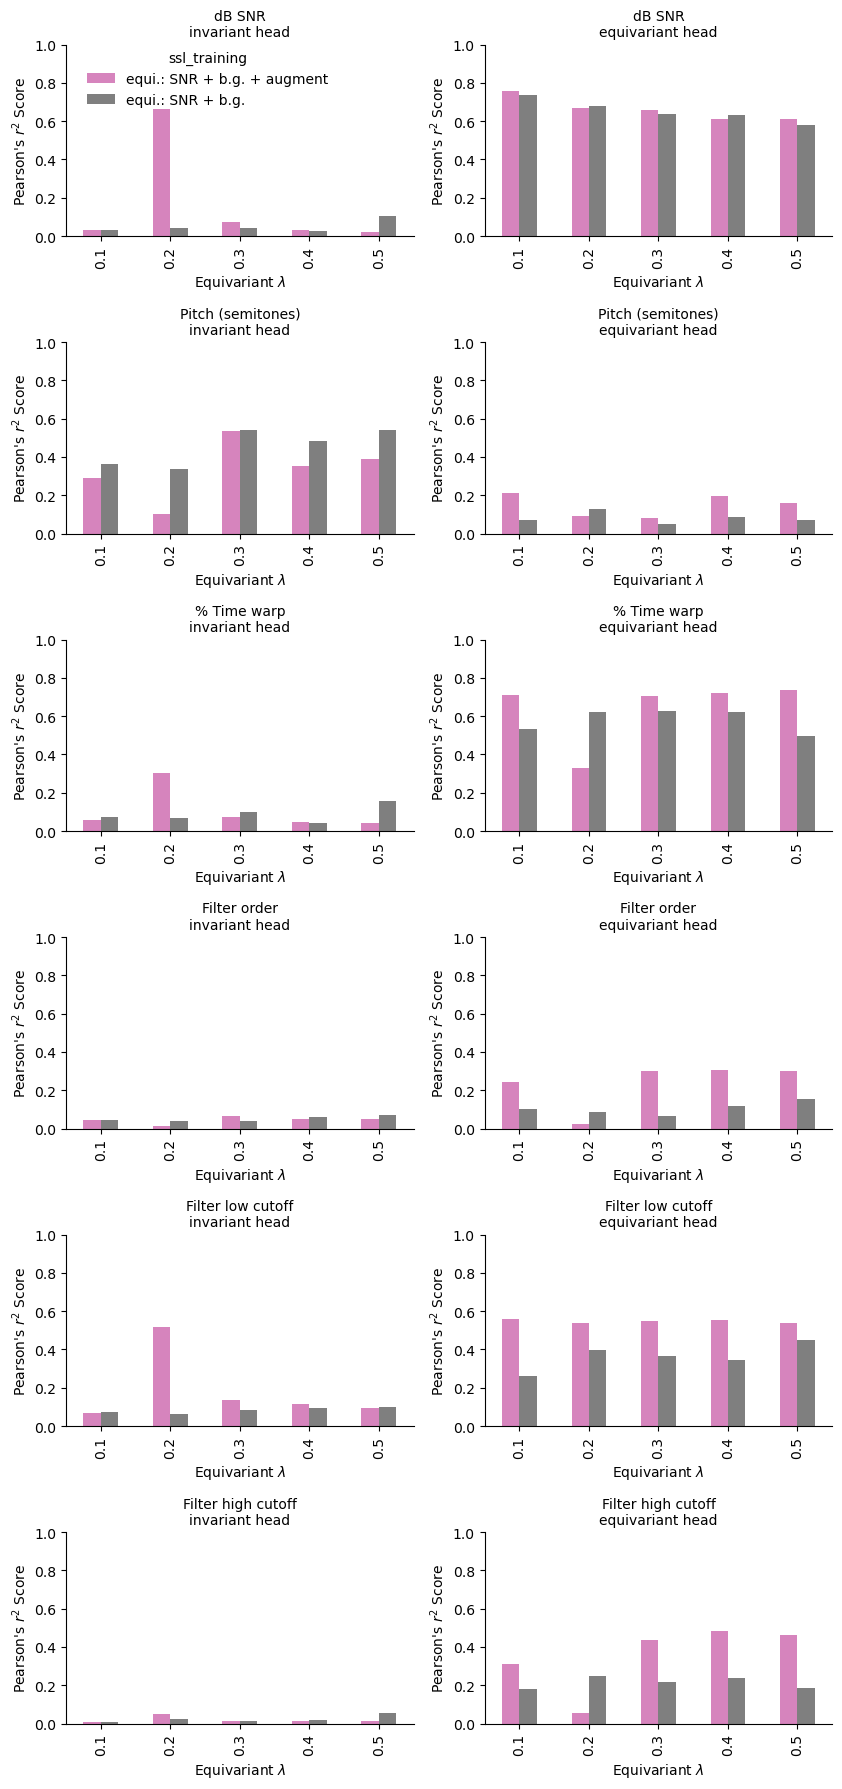

In [85]:
palette = {}
palette['equi.: SNR + b.g. + augment'] = 'tab:pink'
palette['equi.: SNR + b.g.'] = 'tab:grey'

eq_lmbda_order = sorted(ssl_head_df['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=ssl_head_df[ssl_head_df['measure'] == 'pr2'],
            kind = 'bar',
            x='eq_lmbda', 
            y='score', 
            order=eq_lmbda_order,
            hue='ssl_training', 
            col='task_head',
            row='parameter', 
            sharey=False,
            sharex=False,
            width=0.5,
            palette=palette,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name} head")
g.set(xlabel="Equivariant $\\lambda$", ylabel="Pearson's $r^2$ Score")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.4, 0.95])

plt.tight_layout()

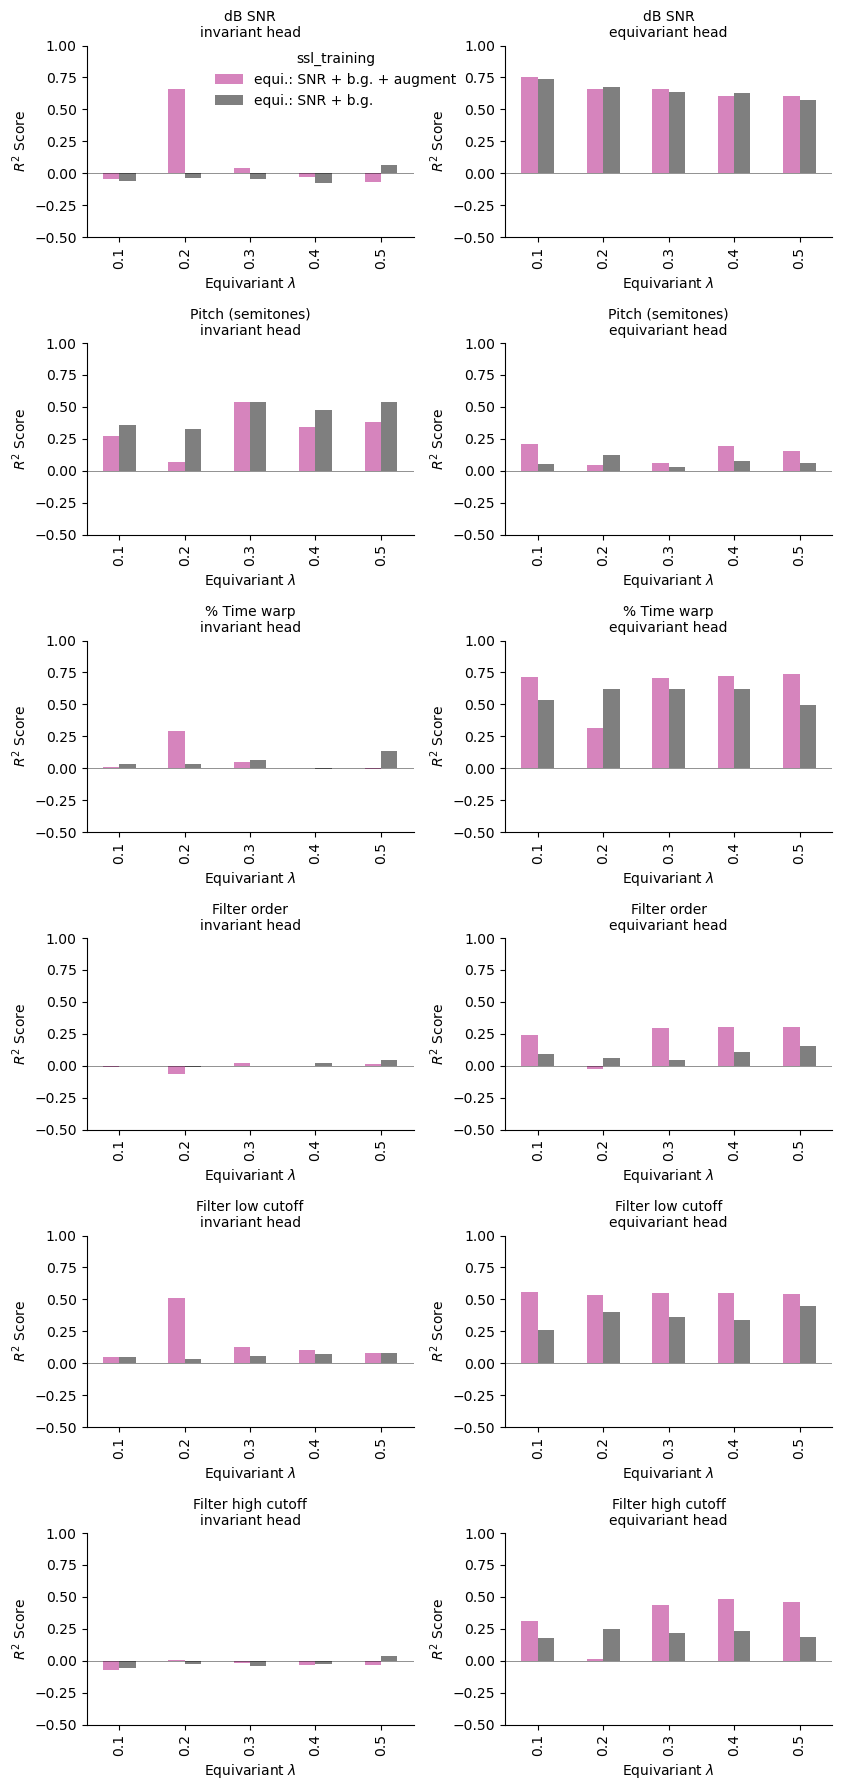

In [81]:
palette = {}
palette['equi.: SNR + b.g. + augment'] = 'tab:pink'
palette['equi.: SNR + b.g.'] = 'tab:grey'

eq_lmbda_order = sorted(ssl_head_df['eq_lmbda'].unique())
# eq_lmbda_order = [0.0, 0.1, 0.5]
g = sns.catplot(data=ssl_head_df[ssl_head_df['measure'] == 'r2'],
            kind = 'bar',
            x='eq_lmbda', 
            y='score', 
            order=eq_lmbda_order,
            hue='ssl_training', 
            col='task_head',
            row='parameter', 
            sharey=False,
            sharex=False,
            width=0.5,
            palette=palette,
            height=3, aspect=1)

g.set_titles("{row_name}\n{col_name} head")
g.set(xlabel="Equivariant $\\lambda$", ylabel="$R^2$ Score")
g.set(ylim=(-0.5,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend
leg.set_bbox_to_anchor([0.55, 0.95])
g.refline(y=0, color='k', linestyle='-', alpha=0.6, linewidth=0.5)

plt.tight_layout()

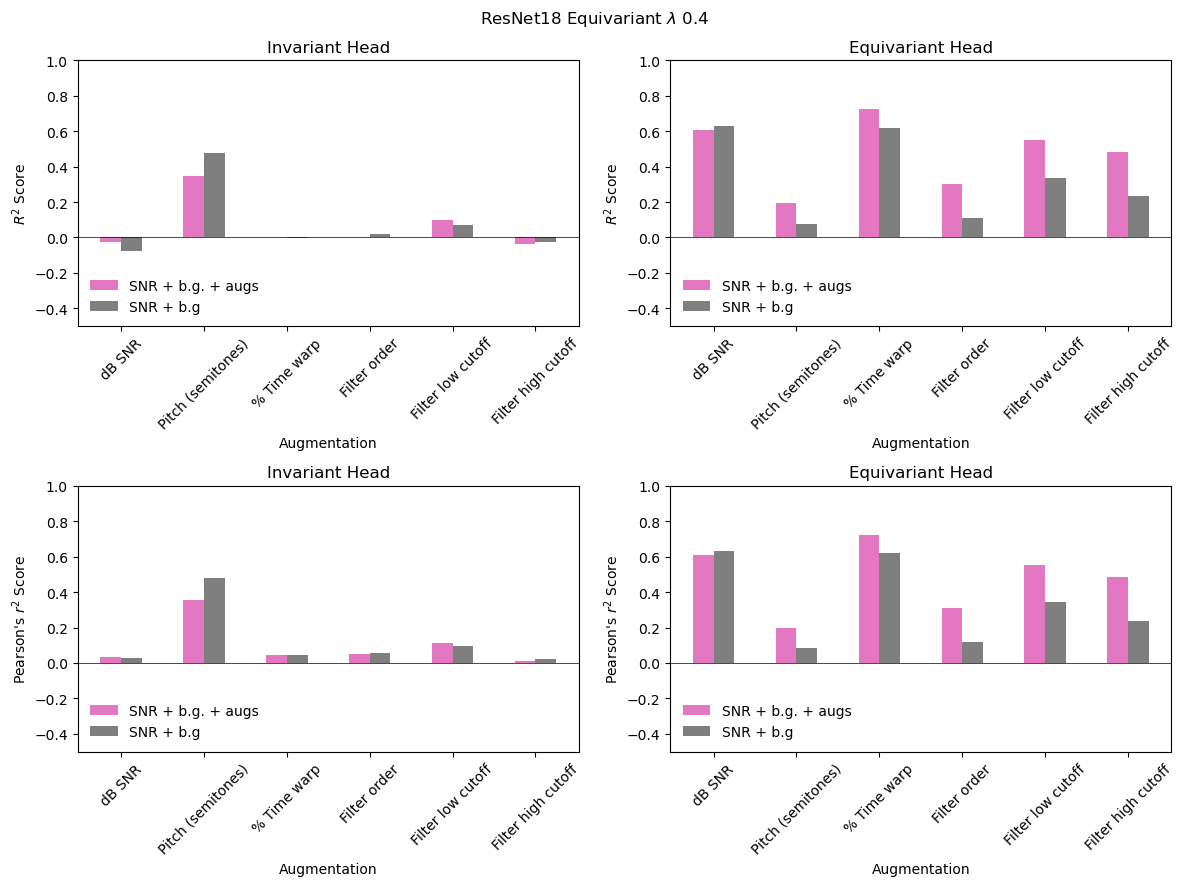

In [8]:
eq_lmbda = 0.4


no_aug_base = f'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_{eq_lmbda:.0e}'
pd_fname  = Path('parameter_decoding') / f"{no_aug_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

no_aug_data = pd.read_pickle(pd_fname)

w_aug_base = f'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_{eq_lmbda:.0e}'
aug_pd_fname  = Path('parameter_decoding') / f"{w_aug_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

aug_data = pd.read_pickle(aug_pd_fname)


fig, axs = plt.subplots(2, 2, figsize=(12,9))
# axs = axs[0,:]
# paxs = axs[1,:]

bar_width = 0.25
param_names = list(aug_data['pr2_invariant_head'].keys())
bar_x = np.arange(len(param_names))
tasks = ['invariant_head', 'equivariant_head']

for ix, head in enumerate(tasks):
    for jx, score in enumerate(['r2', 'pr2']):
        axs[jx, ix].bar(bar_x, aug_data[f"{score}_{head}"].values(), color='tab:pink', label='SNR + b.g. + augs', width=bar_width)
        axs[jx, ix].bar(bar_x + bar_width, no_aug_data[f"{score}_{head}"].values(), color='tab:grey', label='SNR + b.g', width=bar_width)
        axs[jx, ix].axhline(0, color='k', lw=0.5)
        axs[jx, ix].set_xticks(rotation=45, ticks=bar_x + (bar_width * 0.5), labels=param_names)
        axs[jx, ix].set_xlabel('Augmentation')
        axs[jx, ix].legend(loc='lower left', frameon=False)

        if jx == 0:
            axs[jx, ix].set_ylabel("$R^2$ Score")
        else:
            axs[jx, ix].set_ylabel("Pearson's $r^2$ Score")

        axs[jx, ix].set_ylim(-0.5,1)
        axs[jx, ix].set_title(f"{head.replace('_', ' ').title()}")

fig.suptitle(f"ResNet18 Equivariant $\\lambda$ {eq_lmbda}")
plt.tight_layout()